# Fondamentaux de la statistique avec Python

In [1]:
### Bibliothèques utiles 
import numpy as np
import scipy as sp
from scipy.stats import *
import matplotlib.pyplot as plt

## 1. Manipulation des variables aléatoires

### 1.1 Générer des nombres aléatoires

La méthode rvs dans le module scipy.stats est utilisée pour générer des échantillons aléatoires à partir d'une 
distribution probabiliste donnée. Elle est disponible pour toutes les distributions (discrètes et continues) dans scipy.stats. Pour générer un échantillon de taille "size" suivant la distribution "distribution", on utilise la syntaxe suivante:
  
            distribution.rvs(*args, size=, random_state=)
avec 
* *args : Les paramètres spécifiques à la distribution. Par exemple, moyenne (loc), écart-type (scale), n (nombre d'essais) et p (probabilité de succès).
* size : Nombre d'échantillons à générer.
* random_state : Contrôle la reproductibilité des résultats (graine pour le générateur aléatoire). On peut utliser un générateur de nombres aléatoires de NumPy (numpy.random.Generator). Dans ce cas on érit:

            rng = np.random.default_rng(seed=)

Finalement, on enumerate les différentes lois de probabilités souvent utilisées.
* Loi de Bernoulli : bernoulli.rvs(p: pb de succès)
* Loi binomiale : binom.rvs(n,p:pb de succès)
* Loi géométrique : geom.rvs(p:pb de succès)
* Loi de Poisson : poisson.rvs(mu: moyenne)
* Loi uniforme : uniform.rvs(loc : min, scale : max-min)
* Loi exponentielle : expon.rvs(scale : 1/taux)
* Loi normale : norm.rvs(loc : moyenne, scale : écart-type)

In [3]:
# Fixer le générateur aléatoire:
rng = np.random.default_rng(seed=2025)

### 1.1.1 Variables aléatoires discrètes

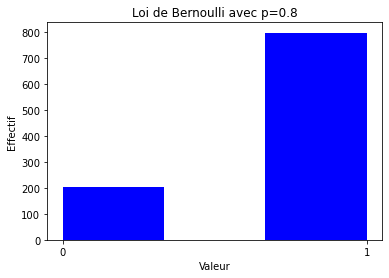

In [4]:
# Loi de Bernoulli
p = 0.8   # Probabilité de succès
n = 1000  # Taille d'échantillons

# Générer un échantillon de taille size=n.
samples = bernoulli.rvs(p, size=n, random_state=rng)

# Affichage des résultats
plt.hist(samples, bins=3, density=False, alpha=1, color='b')
plt.title(f"Loi de Bernoulli avec p={p}")
plt.xlabel("Valeur")
plt.ylabel("Effectif")
plt.xticks([0, 1])
plt.show()

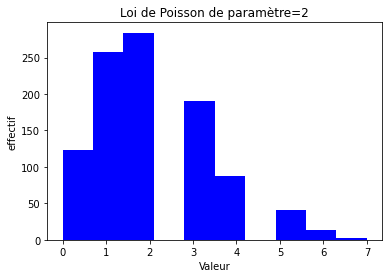

In [4]:
# Loi de Poisson
mu = 2     # moyenne
n  = 1000  # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples = poisson.rvs(mu, size=n, random_state=rng)

# Affichage des résultats
plt.hist(samples, bins=None, density=False, alpha=1, color='b')
plt.title(f"Loi de Poisson de paramètre={mu}")
plt.xlabel("Valeur")
plt.ylabel("effectif")
plt.show()

### 1.1.2 Variables aléatoires continues

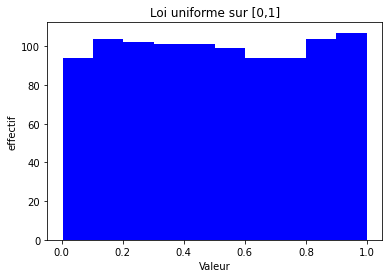

In [5]:
# Loi Uniforme sur [0,1]
loc   = 0     # borne inférieure
scale = 1     # différence entre les bornes
n  = 1000  # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples = uniform.rvs(loc, scale, size=n, random_state=rng)

# Affichage des résultats
plt.hist(samples, bins=None, density=False, alpha=1, color='b')
plt.title(f"Loi uniforme sur [0,1]")
plt.xlabel("Valeur")
plt.ylabel("effectif")
plt.show()

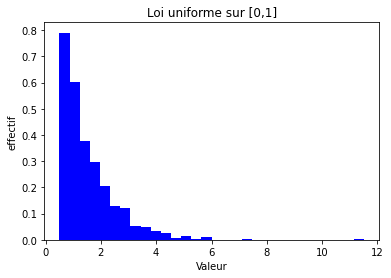

In [6]:
# Loi exponentielle
taux     = 2            # paramètre
scale    = 1/taux     # différence entre les bornes
n        = 1000         # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples = expon.rvs(scale, size=n, random_state=rng)

# Affichage des résultats
plt.hist(samples, bins=30, density=True, alpha=1, color='b')
plt.title(f"Loi uniforme sur [0,1]")
plt.xlabel("Valeur")
plt.ylabel("effectif")
plt.show()

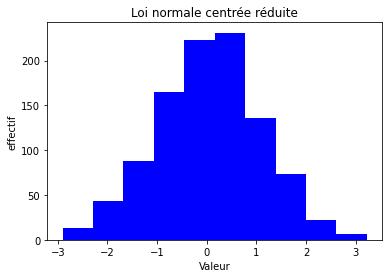

In [7]:
# Loi normale centrée réduite
loc   = 0     # moyenne
scale = 1     # écart type
n  = 1000  # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples = norm.rvs(loc, scale, size=n, random_state=rng)

# Affichage des résultats
plt.hist(samples, bins=None, density=False, alpha=1, color='b')
plt.title(f"Loi normale centrée réduite")
plt.xlabel("Valeur")
plt.ylabel("effectif")
plt.show()

### Remarque:
On peut utiliser la bibliothèque numpy pour générer des nombres aléatoires.

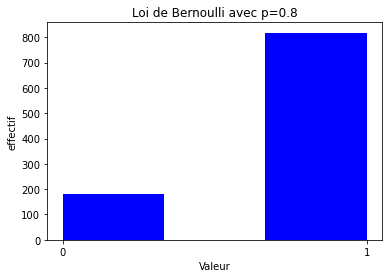

In [8]:
p = 0.8  # Probabilité de succès
n = 1000  # Nombre d'échantillons

# Générer les échantillons (loi de Bernoulli)
samples = np.random.binomial(1, p, size=n)

# Affichage des résultats
plt.hist(samples, bins=3, density=False, alpha=1, color='b')
plt.title(f"Loi de Bernoulli avec p={p}")
plt.xlabel("Valeur")
plt.ylabel("effectif")
plt.xticks([0, 1])
plt.show()

### 1.2 Paramètres statistiques des variables aléatoires

Soit $X$ un vecteur aléatoire. Voici quelques paramètres statistiques de base :

*  Moyenne : La moyenne d'un vecteur aléatoire $X$ peut être calculée avec la fonction: 
     
                                               np.mean(X)
      
*  Variance : La variance d'un vecteur aléatoire $X$ est la mesure de la dispersion de $X$ autour de sa moyenne. Elle peut être calculée avec la fonction: 
     
                                               np.var(X)
      
*  Ecart-type : L'écart-type est la racine carrée de la variance, et il mesure également la dispersion des valeurs autour de la moyenne. Il peut être calculé avec la fonction:

                                               np.std(X)

*  Covariance:  La covariance entre deux variables aléatoires $X$ et $Y$ mesure l'interdépendance entre elles. Elle peut être calculée avec la fonction:

                                               np.cov(X, Y)
* Corrélation:  La corrélation entre deux variables aléatoires $X$ et $Y$ mesure la force et la direction de la relation linéaire entre elles. Elle peut être calculée avec la fonction:

                                               np.corrcoef(X, Y)

### Remarque:
On peut également vérifier graphiquement l'indépendance entre deux vecteur aléatoires en utilisant la fonction:
  
                                                plt.scatter

### Exemple:

In [9]:
loc1, loc2     = 0, 1
scale1, scale2 = 2, 4
X              = norm.rvs(loc1, scale1, size=1000)
Y              = norm.rvs(loc2, scale2, size=1000)
corr_XY        = np.corrcoef(X,Y)
corr_XY

array([[1.        , 0.03264006],
       [0.03264006, 1.        ]])

Le coefficient de corrélation est égal à $-0.029$, ceci  indique qu'il n'existe pratiquement aucune relation linéaire entre 
$𝑋$ et $Y$.

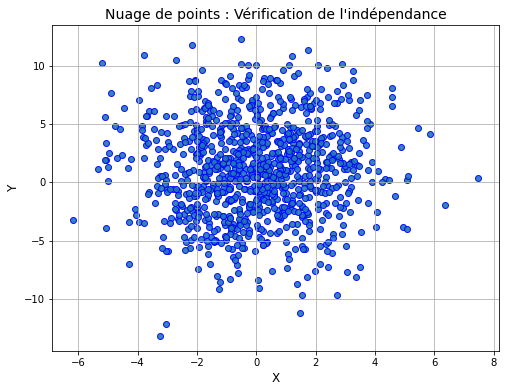

In [10]:
# Vérification graphique de l'indépendance
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, alpha=0.9, edgecolors='b')
plt.title("Nuage de points : Vérification de l'indépendance", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.grid(True)
plt.show()

La dispersion des points est répartie aléatoirement, sans tendance visible. Cela indique qu'il n'existe pas de relation linéaire entre $X$ et $Y$.

## 2. Densité de probabilité et fonction de répartition 

### 2.1 Densité de probabilité

### 2.1.1 Densité de probabilité théorique

Afin de calculer la densité de probabilité (pdf) d'une variable aléatoire continue, on utilise la commande:

                                                 distribution.pdf(x, *args)

avec *args désigne les paramètres spécifiques de la distrubition.

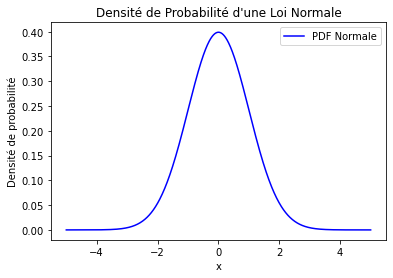

In [11]:
# Représentation graphique de la loi normale centrée réduite
mu = 0      # Moyenne
sigma = 1   # Écart-type

# Générer des points sur l'axe x
x = np.linspace(-5, 5, 1000)

# Calculer la densité de probabilité pour chaque point x
z = norm.pdf(x, loc=mu, scale=sigma)

# Tracer la densité de probabilité
plt.plot(x, z, label='PDF Normale', color='b')
plt.title('Densité de Probabilité d\'une Loi Normale')
plt.xlabel('x')
plt.ylabel('Densité de probabilité')
plt.legend()
plt.show()

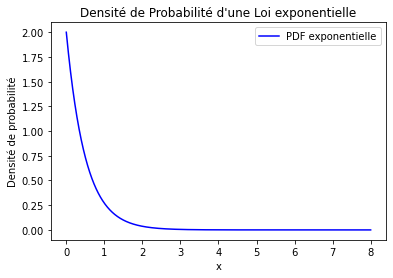

In [12]:
# Représentation graphique de la loi exponentielle
taux = 2      # paramètre 

# Générer des points sur l'axe x
x = np.linspace(0, 8, 1000)

# Calculer la densité de probabilité pour chaque point x
pdf = expon.pdf(x, scale=1/taux)

# Tracer la densité de probabilité
plt.plot(x, pdf, label='PDF exponentielle', color='b')
plt.title('Densité de Probabilité d\'une Loi exponentielle')
plt.xlabel('x')
plt.ylabel('Densité de probabilité')
plt.legend()
plt.show()

### 2.1.2 Densité de probabilité empirique

En statistique, l'estimation par noyau (ou densité de Kernel) est une méthode non paramétrique permettant d'estimer la densité de probabilité d'une variable aléatoire. Contrairement à l'histogramme, qui est une approche discrète, la densité de Kernel offre une estimation continue de la distribution sous-jacente des données. En d'autres termes, elle permet de représenter de manière lissée la fréquence des observations au sein d'un échantillon. Ainsi, la courbe de densité de Kernel constitue une approximation fluide et continue de la distribution des données, offrant une vue plus précise et moins sensible aux variations dues au choix des intervalles (ou bins) utilisés dans les histogrammes. La méthode kde de Scipy permet de calculer la densité de Kernel afin d'estimer la distribution sous-jacente d'un ensemble de données. Elle offre une approche non paramétrique pour obtenir une estimation continue de la densité de probabilité, fournissant ainsi une représentation lissée des données. 

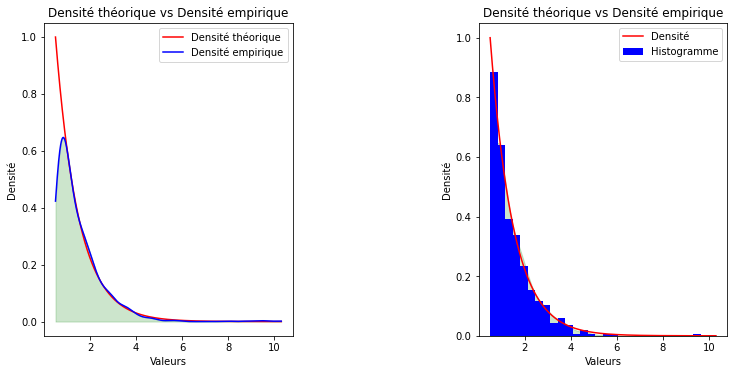

In [13]:
# Estimation de la densité d'un échantillon d'une loi exponentielle
taux     = 2            # paramètre
scale    = 1/taux     # différence entre les bornes
n        = 1000         # Taille d'échantillons
# Générer un échantillon de taille size=n.
data     = expon.rvs(scale, size=n, random_state=rng)
# Estimation de la densité par noyau
kde   = gaussian_kde(data)
x     = np.linspace(min(data), max(data), 1000)
y     = kde(x)
z     = expon.pdf(x, scale)

# Tracer la densité de probabilité théorique 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, z, label='Densité théorique', color='r')
# Tracé de la densité empirique
plt.plot(x, y, label="Densité empirique", color="b")
plt.fill_between(x, y, alpha=0.2, color="green")
# Détails du graphique
plt.title("Densité théorique vs Densité empirique")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.legend()
#
plt.subplot(1, 2, 2)
plt.hist(data, bins=30, density=True, alpha=1, label="Histogramme", color='b')
# Tracé de la densité empirique
plt.plot(x, z, label="Densité", color="r")
plt.fill_between(x, y, alpha=0.2, color="green")
# Détails du graphique
plt.title("Densité théorique vs Densité empirique")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.legend()
#
plt.tight_layout(pad=0)  # Ajuste l'espacement entre les sous-graphiques
plt.subplots_adjust(wspace=0.75)  # Ajuste l'espacement horizontal
plt.show()

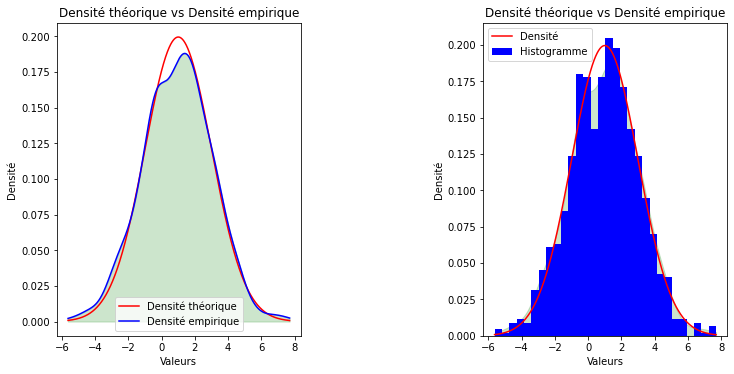

In [14]:
# Estimation de la densité d'un échantillon d'une loi normale
loc     = 1            # paramètre
scale    = 2     # différence entre les bornes
n        = 1000         # Taille d'échantillons
# Générer un échantillon de taille size=n.
data     = norm.rvs(loc, scale, size=n, random_state=rng)
# Estimation de la densité par noyau
kde   = gaussian_kde(data)
x     = np.linspace(min(data), max(data), 1000)
y     = kde(x)
z     = norm.pdf(x, loc, scale)

# Tracer la densité de probabilité théorique 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, z, label='Densité théorique', color='r')
# Tracé de la densité empirique
plt.plot(x, y, label="Densité empirique", color="b")
plt.fill_between(x, y, alpha=0.2, color="green")
# Détails du graphique
plt.title("Densité théorique vs Densité empirique")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.legend()
#
plt.subplot(1, 2, 2)
plt.hist(data, bins=30, density=True, alpha=1, label="Histogramme", color='b')
# Tracé de la densité empirique
plt.plot(x, z, label="Densité", color="r")
plt.fill_between(x, y, alpha=0.2, color="green")
# Détails du graphique
plt.title("Densité théorique vs Densité empirique")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.legend()
#
plt.tight_layout(pad=0)  # Ajuste l'espacement entre les sous-graphiques
plt.subplots_adjust(wspace=0.75)  # Ajuste l'espacement horizontal
plt.show()

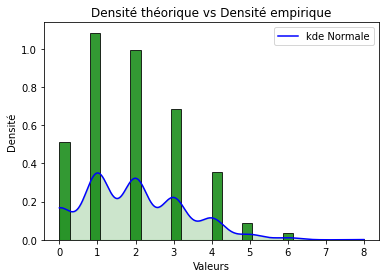

In [15]:
# Estimation de la densité d'un échantillon d'une loi de Poisson
mu = 2     # moyenne
n  = 1000  # Taille d'échantillons

# Générer un échantillon de taille size=n.
data     = poisson.rvs(mu, size=n, random_state=rng)
# Estimation de la densité par noyau
kde   = gaussian_kde(data)
x     = np.linspace(min(data), max(data), 1000)
y     = kde(x)
#z     = poisson.pdf(x, scale)

# Tracer l'histogramme
plt.hist(data, bins=30, density=True, alpha=0.8, color='g', edgecolor='black')
# Tracé de la densité empirique
plt.plot(x, y, label="kde Normale", color="b")
plt.fill_between(x, y, alpha=0.2, color="green")
# Détails du graphique
plt.title("Densité théorique vs Densité empirique")
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.legend()
plt.show()

### 1.3 Fonction de répartition

Afin de calculer la fonction de répartition (cdf) d'une variable aléatoire sur un vecteur $x$, on utilise la commande:

    distribution.cdf(x, *args)

avec *args désigne les paramètres spécifiques de la distrubition.

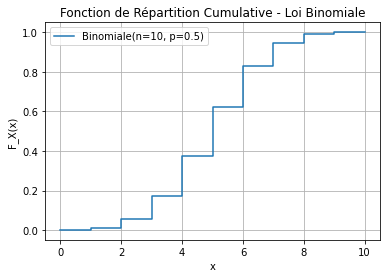

In [16]:
# Fonction de répartition de la loi binomiale
# Paramètres de la loi binomiale
n = 10
p = 0.5

# Calcul des valeurs de F_X(x)
x = np.arange(0, n + 1)
F = binom.cdf(x, n, p)

# Tracé
plt.step(x, F, where='post', label=f"Binomiale(n={n}, p={p})")
plt.title("Fonction de Répartition Cumulative - Loi Binomiale")
plt.xlabel("x")
plt.ylabel("F_X(x)")
plt.grid()
plt.legend()
plt.show()

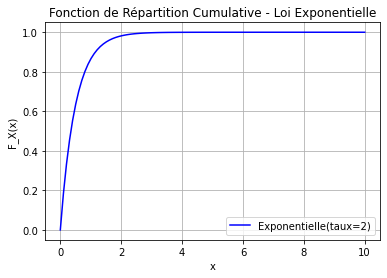

In [17]:
# Fonction de répartition de la loi exponentielle
# Paramètres de la loi binomiale
taux = 2

# Calcul des valeurs de F_X(x)
x = x = np.linspace(0, 10, 100)
F = expon.cdf(x, scale=1/taux)

# Tracé
plt.plot(x, F, label=f"Exponentielle(taux={2})", color="b")
plt.title("Fonction de Répartition Cumulative - Loi Exponentielle")
plt.xlabel("x")
plt.ylabel("F_X(x)")
plt.grid()
plt.legend()
plt.show()

### 1.4 Fonction de répartition empirique

ECDF (pour Empirical cumulative distribution function ou Fonction de distribution cumulative empirique en français) offre une visualisation alternative de la distribution. Il indique, pour un nombre donné, le pourcentage de personnes qui se situent en dessous de ce seuil.

### Définition

Soit $X$ une variable aléatoire et $x=(x_1, \dots, x_n)$ $n$ réalisation de $X$. Alors la fonction ECDF du vecteur $x$ notée $F_n$ est définie par l'expression suivante:
\begin{align*}
F_n(t)= \frac{1}{n}\,\sum^{n}_{i=1}\,\mathbf{1}_{x_i \leq t}, \;\; \forall t \in \mathbb{R}
\end{align*}



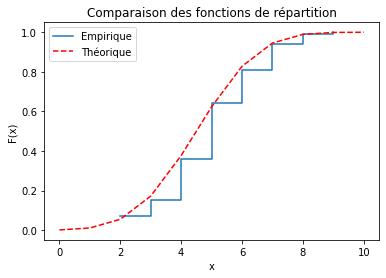

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Données simulées (par exemple, une variable suivant une loi binomiale)
n, p = 10, 0.5
data = np.random.binomial(n, p, 100)

# Calcul de la CDF empirique
values, counts = np.unique(data, return_counts=True)
empirical_cdf = np.cumsum(counts) / len(data)

# CDF théorique (binomiale)
x = np.arange(0, n+1)
theoretical_cdf = binom.cdf(x, n, p)

# Visualisation
plt.step(values, empirical_cdf, label="Empirique", where="post")
plt.plot(x, theoretical_cdf, label="Théorique", color="red", linestyle="--")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Comparaison des fonctions de répartition")
plt.legend()
plt.show()

### 3.1 Test de Shapiro-Wilk

Le test de Shapiro-Wilk permet de vérifier la normalité d'une variable. Il est appliquable pour des échantillons allant jusqu'à 50 valeurs. Les hypothèses de ce test sont les suivantes:
* $H_0$: Les données suivent une distribution normale.
* $H_1$: Les données ne suivent pas une distribution normale.

la syntaxe pour effectuer un test de Shapiro-Wilk à l'aide de la bibliothèque scipy.stats est la suivante:

        shapiro(data)

### 3.2 Test de Kolmogorov-Smirnov

En statistiques, le test de Kolmogorov-Smirnov est un test d'hypothèse utilisé pour déterminer si un échantillon suit bien une loi donnée connue par sa fonction de répartition continue, ou bien si deux échantillons suivent la même loi. Les hypothèses de ce test sont les suivantes:
* $H_0$: La distribution empirique suit la distribution théorique spécifiée (ou que les deux distributions comparées sont identiques).
* $H_1$: La distribution empirique ne suit pas la distribution théorique spécifiée (ou que les deux distributions comparées sont différentes).

la syntaxe pour effectuer un test de Kolmogorov-Smirnov (KS) à l'aide de la bibliothèque scipy.stats est la suivante:

        scipy.stats.kstest(rvs, cdf, args=(), N=20, alternative='two-sided', mode='auto')
        
        
Le test de Kolmogorov-Smirnov est par exemple utilisé pour tester la qualité d'un générateur de nombres aléatoires.

### Exemple:

In [19]:
taux     = 2            # paramètre
scale    = 1/taux     # différence entre les bornes
n        = 1000         # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples  = expon.rvs(scale, size=n, random_state=rng)
test     = kstest(samples, 'expon', args=(scale,))
test

KstestResult(statistic=0.026428179475744884, pvalue=0.47917143117821437)

In [20]:
taux     = 2            # paramètre
scale    = 1/taux     # différence entre les bornes
n        = 1000         # Taille d'échantillons
# Générer un échantillon de taille size=n.
samples  = expon.rvs(scale, size=n, random_state=rng)
test     = kstest(samples, 'expon', args=(0.5,))
test

KstestResult(statistic=0.035332299928262256, pvalue=0.16076504662896318)

### Remarque:
Le test de Kolmogorov n'est plus valable pour les lois discrètes.

### 3.2 Test du Khi-deux

Le test du $\chi^2$ d'adéquation ou de conformité permet de vérifier si un échantillon d'une variable aléatoire discrète $Y$ donne des observations comparables à celles d'une loi de probabilité P définie a priori dont on pense, pour des raisons théoriques ou pratiques, qu'elle devrait être la loi de Y. Les hypothèses de ce test sont les suivantes:
* $H_0$: Les données suivent la distribution théorique.
* $H_1$: Les données ne suivent pas la distribution théorique.

la syntaxe pour effectuer un test de Kolmogorov-Smirnov (KS) à l'aide de la bibliothèque scipy.stats est la suivante:

        scipy.stats.kstest(rvs, cdf, args=(), N=20, alternative='two-sided', mode='auto')